<a href="https://colab.research.google.com/github/Quite-my-Tempo/Sinais-e-Sistemas-em-Tempo-Discreto/blob/main/Projeto_2_Filtros_ECG/projeto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [ ]:
#Código das funções utilizadas.
def filtro_notch(x, fs=500.0, f0=60.0, r=0.9):

    omega_0 = 2 * np.pi * f0 / fs

    coef_y1 = 2 * r * np.cos(omega_0)
    coef_y2 = r**2
    coef_x1 = 2 * np.cos(omega_0)

    N = len(x)
    y = np.zeros(N)


    for n in range(N):
        y_n_1 = y[n-1] if n >= 1 else 0.0
        y_n_2 = y[n-2] if n >= 2 else 0.0

        x_n_1 = x[n-1] if n >= 1 else 0.0
        x_n_2 = x[n-2] if n >= 2 else 0.0

        # y[n] = 1.3121*y[n-1] - 0.81*y[n-2] + x[n] - 1.4579*x[n-1] + x[n-2]
        y[n] = coef_y1 * y_n_1 - coef_y2 * y_n_2 + x[n] - coef_x1 * x_n_1 + x_n_2

    return y

def filtro_passa_baixas(x, fs=500.0, fc=35.0, r=0.9):

    omega_c = 2 * np.pi * fc / fs
    coef_y1 = 2 * r * np.cos(omega_c)
    coef_y2 = r**2


    N = len(x)
    y = np.zeros(N)


    for n in range(N):

        y_n_1 = y[n-1] if n >= 1 else 0.0
        y_n_2 = y[n-2] if n >= 2 else 0.0


        x_n_1 = x[n-1] if n >= 1 else 0.0
        x_n_2 = x[n-2] if n >= 2 else 0.0

        y[n] = coef_y1 * y_n_1 - coef_y2 * y_n_2 + x[n] + 2 * x_n_1 + x_n_2

    return y

# Questão 1

Um sistema de aquisição de dados de eletrocardiograma foi ligado de forma equivocada perto demais da rede elétrica. Assim, a interferência da rede elétrica (a 60 Hz) aparece de forma marcante no sinal adquirido. O seu objetivo é projetar um filtro digital para eliminar totalmente o ruído em 60Hz. A frequência de amostragem do sistema é:

$$ f_a = 500~Hz $$

Siga as questões abaixo.

## Questão 1a (0.5  pontos)

Projete o filtro em questão utilizando a colocação de pólos e zeros no plano z. Desenhe o diagrama de pólos e zeros do filtro projetado, indicando quais pólos e zeros foram indicados e o porquê destes pólos/zeros terem sido escolhidos. Você pode inserir o seu projeto como uma imagem escaneada abaixo.

In [ ]:
#Resposta da questão 1a
z1, z2 = np.exp(1j * 6 * np.pi / 25), np.exp(-1j * 6 * np.pi / 25)
p1, p2 = 0.9 * z1, 0.9 * z2


## Questão 1b (0.5 pontos)

A partir do diagrama desenvolvido na questão anterior, escreva a função de transferência do filtro H(z) e a equação de diferenças do sistema que realiza o filtro. Você pode inserir sua resposta como uma imagem escaneada abaixo.

In [ ]:
#Resposta da questão 1b
def filtro_notch(x, fs=500.0, f0=60.0, r=0.9):

    omega_0 = 2 * np.pi * f0 / fs

    coef_y1 = 2 * r * np.cos(omega_0)
    coef_y2 = r**2
    coef_x1 = 2 * np.cos(omega_0)

    N = len(x)
    y = np.zeros(N)


    for n in range(N):
        y_n_1 = y[n-1] if n >= 1 else 0.0
        y_n_2 = y[n-2] if n >= 2 else 0.0

        x_n_1 = x[n-1] if n >= 1 else 0.0
        x_n_2 = x[n-2] if n >= 2 else 0.0

        # y[n] = 1.3121*y[n-1] - 0.81*y[n-2] + x[n] - 1.4579*x[n-1] + x[n-2]
        y[n] = coef_y1 * y_n_1 - coef_y2 * y_n_2 + x[n] - coef_x1 * x_n_1 + x_n_2

    return y

## Questão 1c (1  ponto)

Plote a **resposta em frequência** do filtro projetado (magnitude e fase).

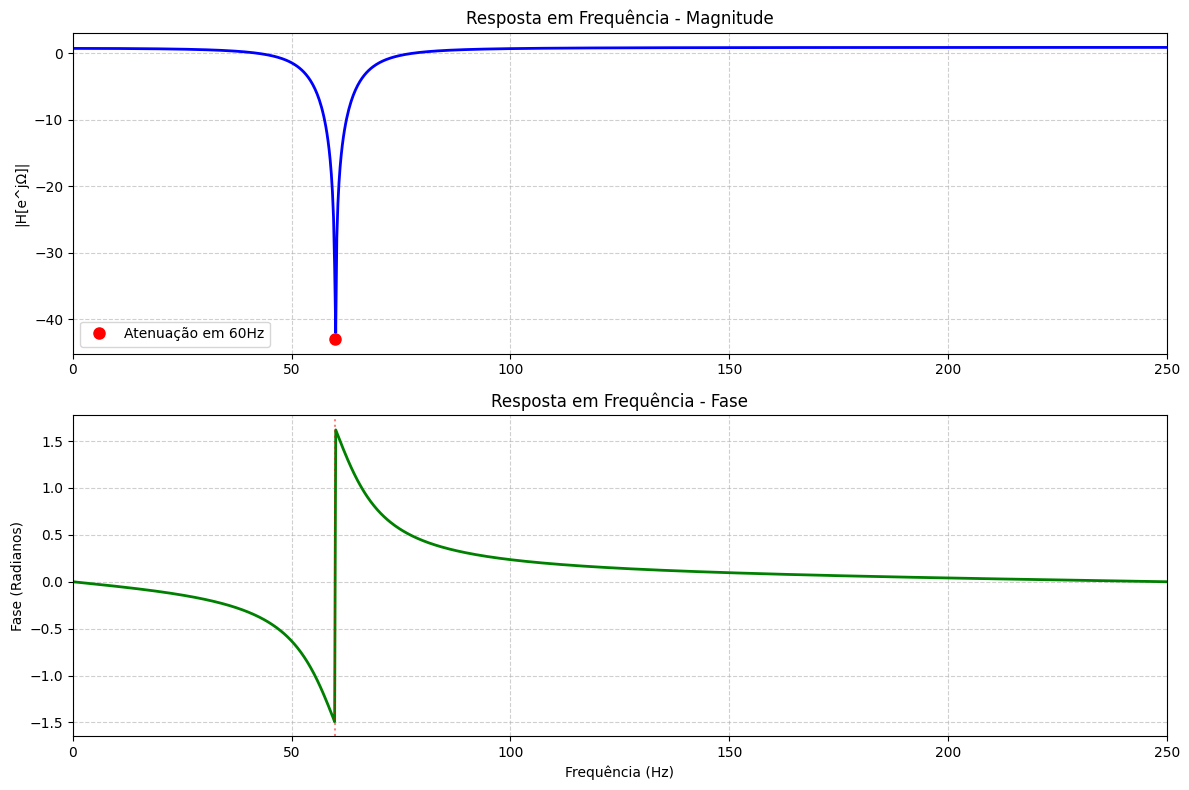

In [ ]:
#Resposta da questão 1c
fs = 500.0
f0 = 60.0
omega_0 = 2 * np.pi * f0 / fs
r = 0.9

#(b = numerador, a = denominador)
b0 = 1.0
b1 = -2 * np.cos(omega_0)
b2 = 1.0

a0 = 1.0
a1 = -2 * r * np.cos(omega_0)
a2 = r**2

f = np.linspace(0, fs/2, 1000)

Omega = 2 * np.pi * f / fs


z_inv_1 = np.exp(-1j * Omega)
z_inv_2 = np.exp(-1j * 2 * Omega)


Numerador = b0 + (b1 * z_inv_1) + (b2 * z_inv_2)
Denominador = a0 + (a1 * z_inv_1) + (a2 * z_inv_2)

H_omega = Numerador / Denominador

magnitude = np.abs(H_omega)
magnitude_db = 20 * np.log10(np.maximum(magnitude, 1e-10))
fase = np.angle(H_omega)


plt.figure(figsize=(12, 8))

# Gráfico da Magnitude
plt.subplot(2, 1, 1)
plt.plot(f, magnitude_db, 'b-', linewidth=2)
plt.plot(60, -43, 'ro', markersize=8, label='Atenuação em 60Hz')
plt.title('Resposta em Frequência - Magnitude')
plt.ylabel('|H[e^jΩ]|')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(0, 250)

# Gráfico da Fase
plt.subplot(2, 1, 2)
plt.plot(f, fase, 'g-', linewidth=2)
plt.title('Resposta em Frequência - Fase')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (Radianos)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(60, color='r', linestyle=':', alpha=0.5)
plt.xlim(0, 250)

plt.tight_layout()
plt.show()

## Questão 1d (0.5  pontos)

Carregue o sinal de ECG "noisy_ecg_data.mat" e aplique o filtro projetado neste sinal. Plote o sinal antes da filtragem (x[n]) e o sinal após a filtragem (y[n]).

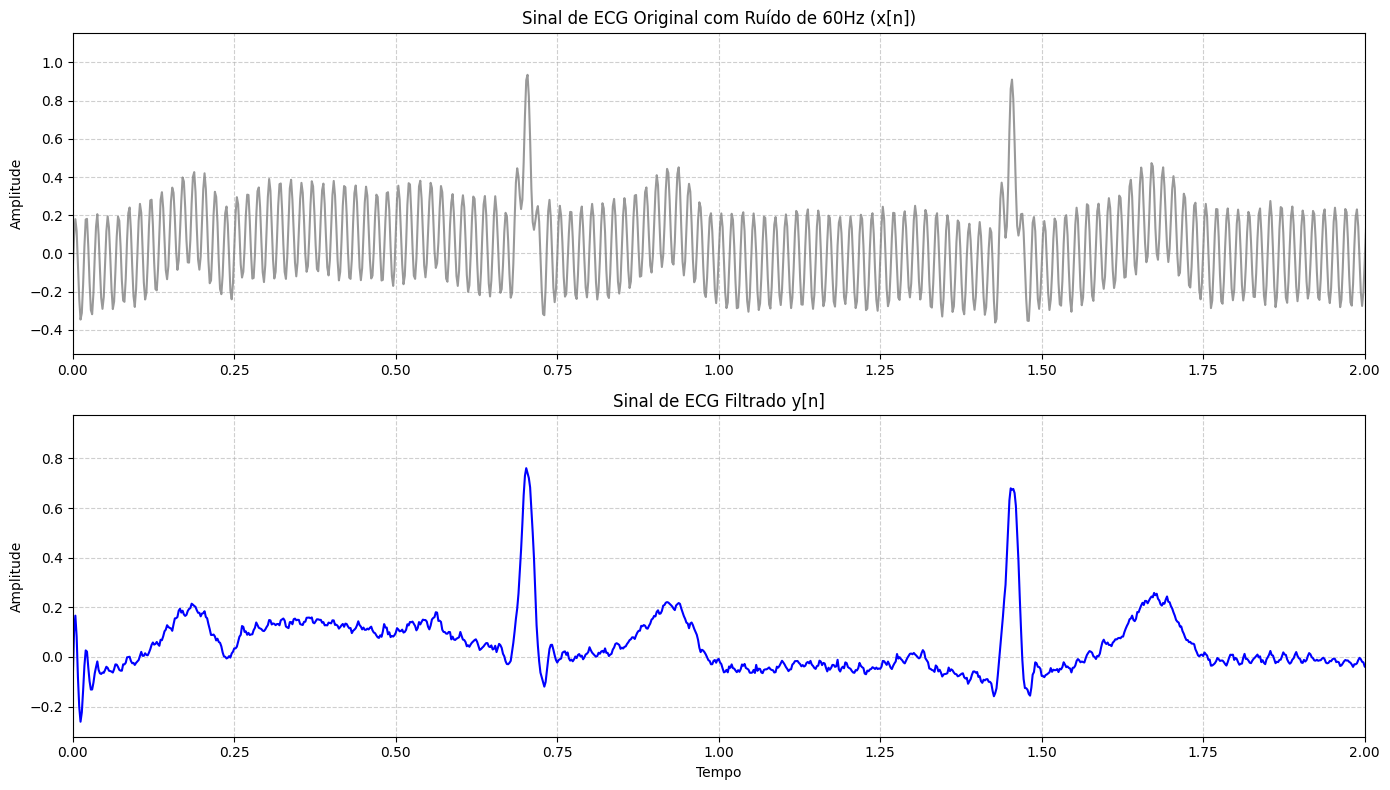

In [ ]:
#Resposta da questão 1d

sinal = sp.io.loadmat('noisy_ecg_data.mat')['noisy_ecg'].ravel()

y = filtro_notch(sinal)
fs = 500.0
N = len(sinal)
tempo = np.arange(N) / fs


plt.figure(figsize=(14, 8))


plt.subplot(2, 1, 1)
plt.plot(tempo, sinal, 'gray', alpha=0.8)
plt.title('Sinal de ECG Original com Ruído de 60Hz (x[n])')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 2)

plt.subplot(2, 1, 2)
plt.plot(tempo, y, 'b', linewidth=1.5)
plt.title('Sinal de ECG Filtrado y[n]')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 2)

plt.tight_layout()
plt.show()

# Questão 2

Ainda no sistema de aquisição de dados de eletrocardiograma, mais tarde foi verificado que, mesmo depois de resolvido o problema da interferência da rede elétrica (i.e., o sinal não tem um ruído específico em 60Hz), o sinal adquirido tinha bastante ruído de alta frequência (acima de 35Hz). O objetivo desta questão é projetar um filtro digital para atenuar as frequências acima de 35Hz. A frequêencia de amostragem do sistema é:

$$ f_a = 500~Hz $$

Siga as questões abaixo.

## Questão 2a (0.5  pontos)

Projete o filtro em questão utilizando a colocação de pólos e zeros no plano z. Desenhe o diagrama de pólos e zeros do filtro projetado, indicando quais pólos e zeros foram indicados e o porquê destes pólos/zeros terem sido escolhidos. Você pode inserir o seu projeto como uma imagem escaneada abaixo.

In [ ]:
#Resposta da questão 2a
p1, p2 = 0.9 * np.exp(1j * 7 * np.pi / 50), 0.9 * np.exp(-1j * 7 * np.pi / 50)
z1, z2 = -1, -1

## Questão 2b (0.5 pontos)

A partir do diagrama desenvolvido na questão anterior, escreva a função de transferência do filtro H(z) e a equação de diferenças do sistema que realiza o filtro. Você pode inserir sua resposta como uma imagem escaneada abaixo.

In [ ]:
#Resposta da questão 2b
def filtro_passa_baixas(x, fs=500.0, fc=35.0, r=0.9):

    omega_c = 2 * np.pi * fc / fs
    coef_y1 = 2 * r * np.cos(omega_c)
    coef_y2 = r**2


    N = len(x)
    y = np.zeros(N)


    for n in range(N):

        y_n_1 = y[n-1] if n >= 1 else 0.0
        y_n_2 = y[n-2] if n >= 2 else 0.0


        x_n_1 = x[n-1] if n >= 1 else 0.0
        x_n_2 = x[n-2] if n >= 2 else 0.0

        y[n] = coef_y1 * y_n_1 - coef_y2 * y_n_2 + x[n] + 2 * x_n_1 + x_n_2

    return y

## Questão 2c (1  ponto)

Plote a **resposta em frequência** do filtro projetado (magnitude e fase).

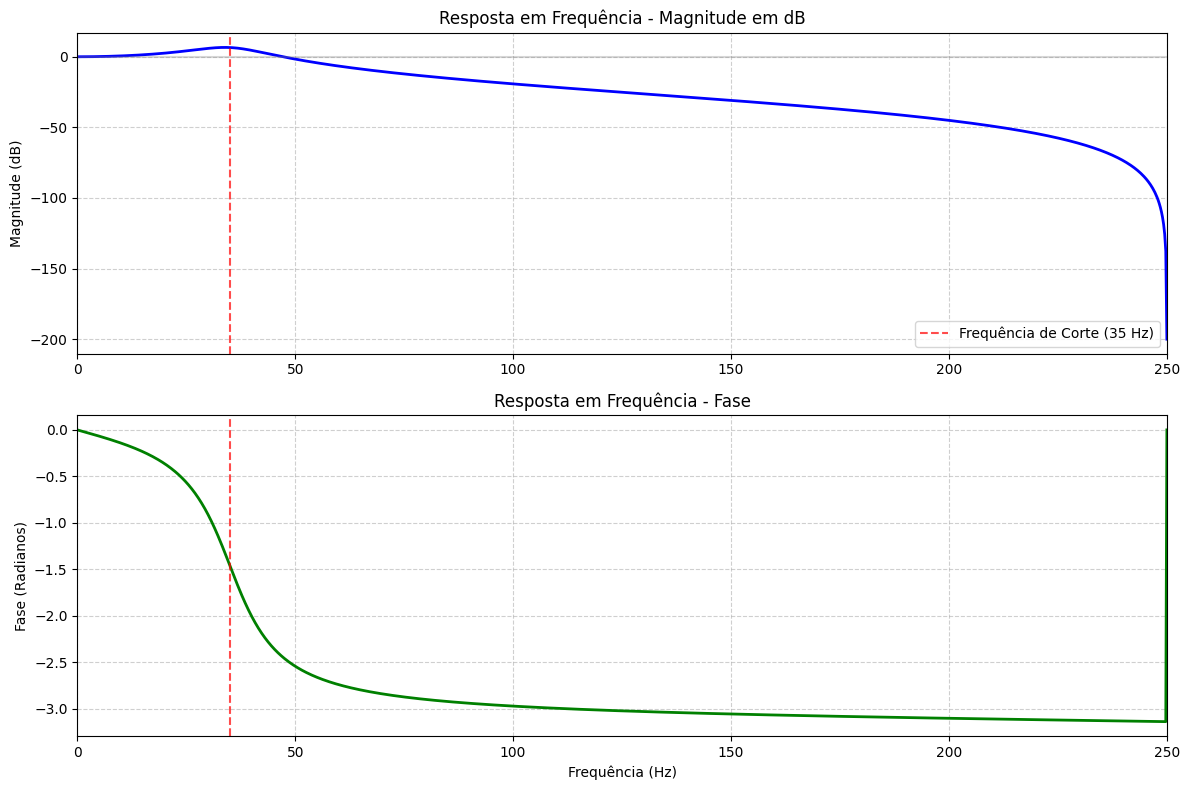

In [ ]:
#Resposta da questão 2c
fs = 500.0
fc = 35.0
omega_c = 2 * np.pi * fc / fs
r = 0.9

b0, b1, b2 = 1.0, 2.0, 1.0
a0 = 1.0
a1 = -2 * r * np.cos(omega_c)
a2 = r**2


# Em 0 Hz, z = e^0 = 1. Então a soma dos coeficientes nos dá o ganho.
ganho_dc = (b0 + b1 + b2) / (a0 + a1 + a2)

b0_norm = b0 / ganho_dc
b1_norm = b1 / ganho_dc
b2_norm = b2 / ganho_dc

f = np.linspace(0, fs/2, 1000)
Omega = 2 * np.pi * f / fs

z_inv_1 = np.exp(-1j * Omega)
z_inv_2 = np.exp(-1j * 2 * Omega)


Numerador = b0_norm + (b1_norm * z_inv_1) + (b2_norm * z_inv_2)
Denominador = a0 + (a1 * z_inv_1) + (a2 * z_inv_2)

H_omega = Numerador / Denominador

magnitude = np.abs(H_omega)
magnitude_db = 20 * np.log10(np.maximum(magnitude, 1e-10))
fase = np.angle(H_omega)

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(f, magnitude_db, 'b-', linewidth=2)

plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(35, color='r', linestyle='--', alpha=0.7, label='Frequência de Corte (35 Hz)')

plt.title('Resposta em Frequência - Magnitude em dB')
plt.ylabel('Magnitude (dB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(0, 250)

plt.subplot(2, 1, 2)
plt.plot(f, fase, 'g-', linewidth=2)
plt.axvline(35, color='r', linestyle='--', alpha=0.7)
plt.title('Resposta em Frequência - Fase')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (Radianos)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 250)

plt.tight_layout()
plt.show()

## Questão 2d (0.5  pontos)

Carregue o sinal de ECG "noisy_ecg_data_2.mat" e aplique o filtro projetado neste sinal. Plote o sinal antes da filtragem (x[n]) e o sinal após a filtragem (y[n]).

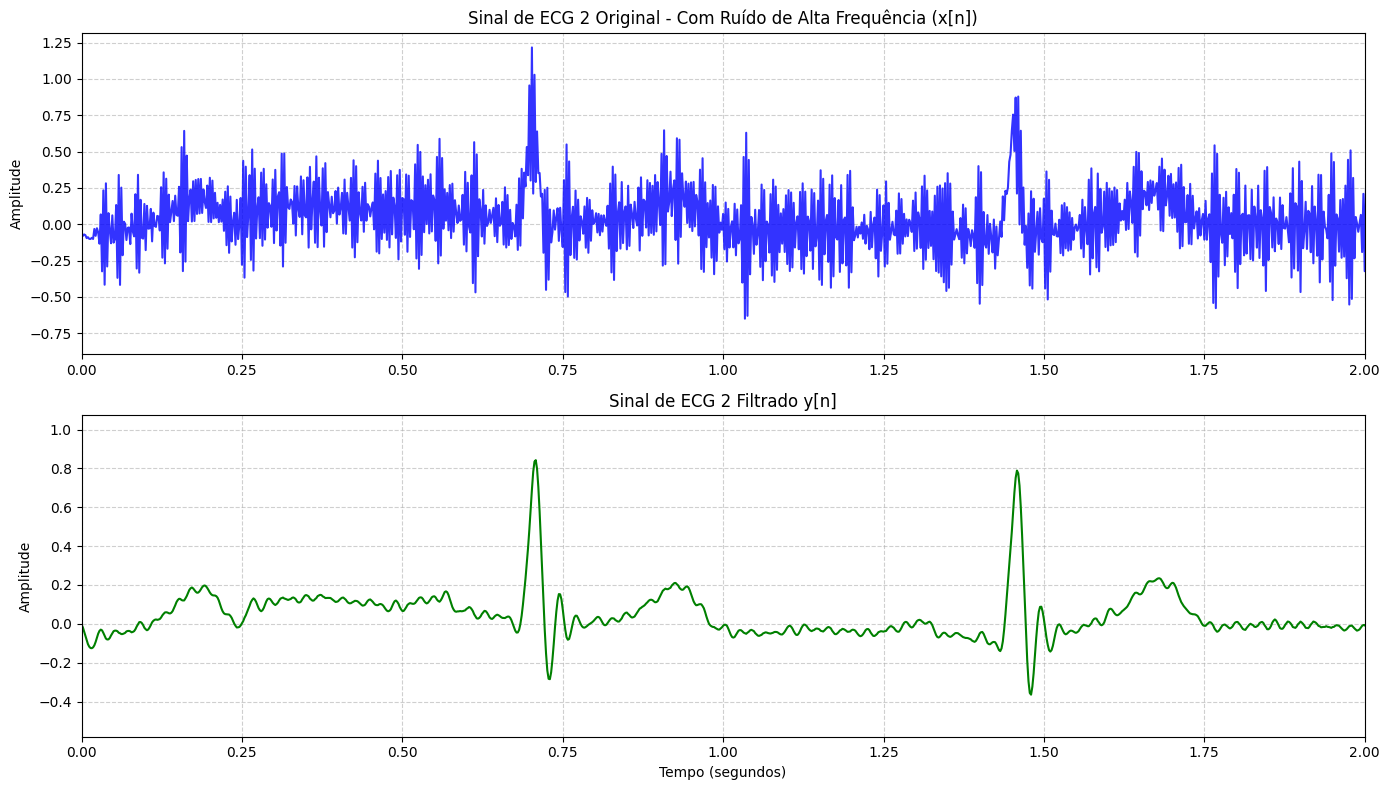

In [ ]:
#Resposta da questão 2d

sinal = sp.io.loadmat('noisy_ecg_data_2.mat')['noisy_ecg2'].ravel()

y = filtro_passa_baixas(sinal)

fs = 500.0
N = len(sinal)
tempo = np.arange(N) / fs


plt.figure(figsize=(14, 8))


plt.subplot(2, 1, 1)
plt.plot(tempo, sinal, 'blue', alpha=0.8)
plt.title('Sinal de ECG 2 Original - Com Ruído de Alta Frequência (x[n])')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(0, 2)

plt.subplot(2, 1, 2)
plt.plot(tempo, y/22.06, 'g', linewidth=1.5)
plt.title('Sinal de ECG 2 Filtrado y[n]')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 2)

plt.tight_layout()
plt.show()

# Questão 3

Considere o filtro analógico:

$$ H_a \left(s\right) = \frac{\omega_c}{\omega_c + s}$$

E considere o valor:

$$\omega_c = 10^3 $$

## Questão 3a (1  ponto)

Projete uma aproximação digital para este filtro com critério de 10%. Indique a taxa de amostragem calculada para esta aproximação (T1) e compare a resposta em frequência do filtro projetado H1() com a resposta em frequência do filtro analógic Ha(). Plote as frequências até ao menos:

$$ \omega = 10^5 \pi $$

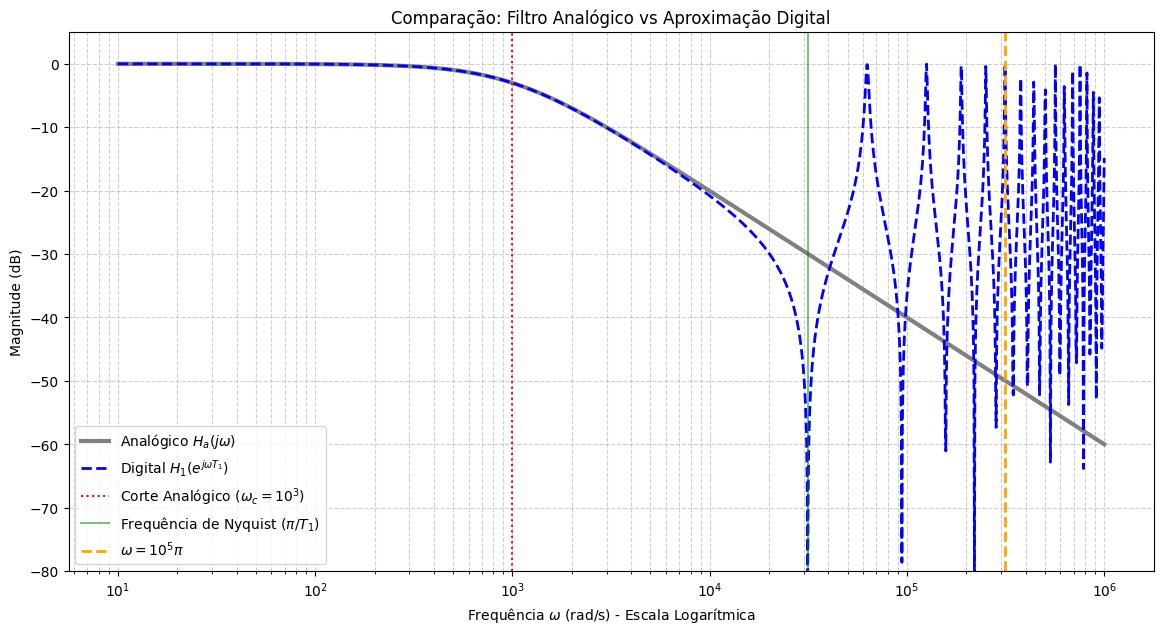

In [ ]:
#Resposta da questão 3a
wc = 1000.0
T = 10**-4  # 10^-4 segundos (Critério de 10%)

w = np.logspace(1, 6, 2000)

# Resposta do Filtro Analógico: Ha(s) = wc / (s + wc), com s = jw
s = 1j * w
Ha = wc / (wc + s)
mag_Ha_dB = 20 * np.log10(np.abs(Ha))


z = np.exp(1j * w * T)

# Numerador e denominador
Num = (1/21) + (1/21)*(z**-1)
Den = 1.0 - (19/21)*(z**-1)
H1 = Num / Den

# Previnir log de zero (quando H1 bate exatamente em Nyquist)
mag_H1_linear = np.abs(H1)
mag_H1_dB = 20 * np.log10(np.maximum(mag_H1_linear, 10**-10))

plt.figure(figsize=(14, 7))

plt.semilogx(w, mag_Ha_dB, 'gray', linewidth=3, label=r'Analógico $H_a(j\omega)$')
plt.semilogx(w, mag_H1_dB, 'b--', linewidth=2, label=r'Digital $H_1(e^{j\omega T_1})$')

plt.axvline(wc, color='r', linestyle=':', label=r'Corte Analógico ($\omega_c = 10^3$)')

w_nyquist = np.pi / T
plt.axvline(w_nyquist, color='g', linestyle='-', alpha=0.5, label=rf'Frequência de Nyquist ($\pi/T_1$)')

plt.axvline(10**5 * np.pi, color='orange', linestyle='--', linewidth=2, label=r'$\omega = 10^5\pi$')

plt.title('Comparação: Filtro Analógico vs Aproximação Digital')
plt.xlabel(r'Frequência $\omega$ (rad/s) - Escala Logarítmica')
plt.ylabel('Magnitude (dB)')
plt.ylim(-80, 5)
plt.legend(loc='lower left')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

## Questão 3b (1  ponto)

Projete uma aproximação digital para este filtro com critério de 1%. Indique a taxa de amostragem calculada para esta aproximação (T2) e compare a resposta em frequência do filtro projetado H2() com a resposta em frequência do filtro analógic Ha(). Plote as frequências até ao menos:

$$ \omega = 10^5 \pi $$

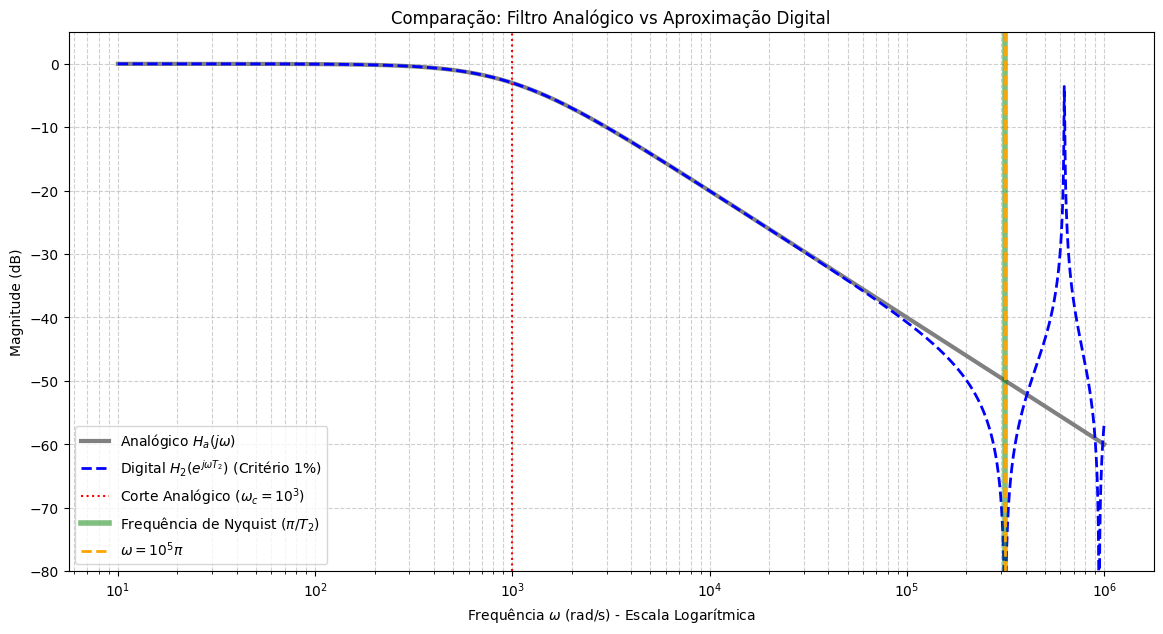

In [ ]:
#Resposta da questão 3b
wc = 1000.0
T2 = 10**-5

w = np.logspace(1, 6, 2000)

# Resposta do Filtro Analógico
s = 1j * w
Ha = wc / (wc + s)
mag_Ha_dB = 20 * np.log10(np.abs(Ha))

# Resposta do Filtro Digital H(z)
z = np.exp(1j * w * T2)

# Coeficientes deduzidos para 1%
Num = (1/201) + (1/201)*(z**-1)
Den = 1.0 - (199/201)*(z**-1)
H2 = Num / Den

# Previnir log de zero
mag_H2_linear = np.abs(H2)
mag_H2_dB = 20 * np.log10(np.maximum(mag_H2_linear, 1e-10))

plt.figure(figsize=(14, 7))

# Curvas
plt.semilogx(w, mag_Ha_dB, 'gray', linewidth=3, label=r'Analógico $H_a(j\omega)$')
plt.semilogx(w, mag_H2_dB, 'b--', linewidth=2, label=r'Digital $H_2(e^{j\omega T_2})$ (Critério 1%)')

# Marcadores
plt.axvline(wc, color='r', linestyle=':', label=r'Corte Analógico ($\omega_c = 10^3$)')

w_nyquist = np.pi / T2

plt.axvline(w_nyquist, color='g', linestyle='-', linewidth=4, alpha=0.5, label=rf'Frequência de Nyquist ($\pi/T_2$)')

plt.axvline(10**5 * np.pi, color='orange', linestyle='--', linewidth=2, label=r'$\omega = 10^5\pi$')

plt.title('Comparação: Filtro Analógico vs Aproximação Digital')
plt.xlabel(r'Frequência $\omega$ (rad/s) - Escala Logarítmica')
plt.ylabel('Magnitude (dB)')
plt.ylim(-80, 5)
plt.legend(loc='lower left')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

## Questão 3c (1 ponto)

Calcule a resposta ao impulso ha(t) do filtro analógico Ha(s), bem como as respostas ao impulso h1[n] e h2[n] dos filtros projetados H1(z) e H2(z). **Plote** as respostas ao impulso na mesma escala.

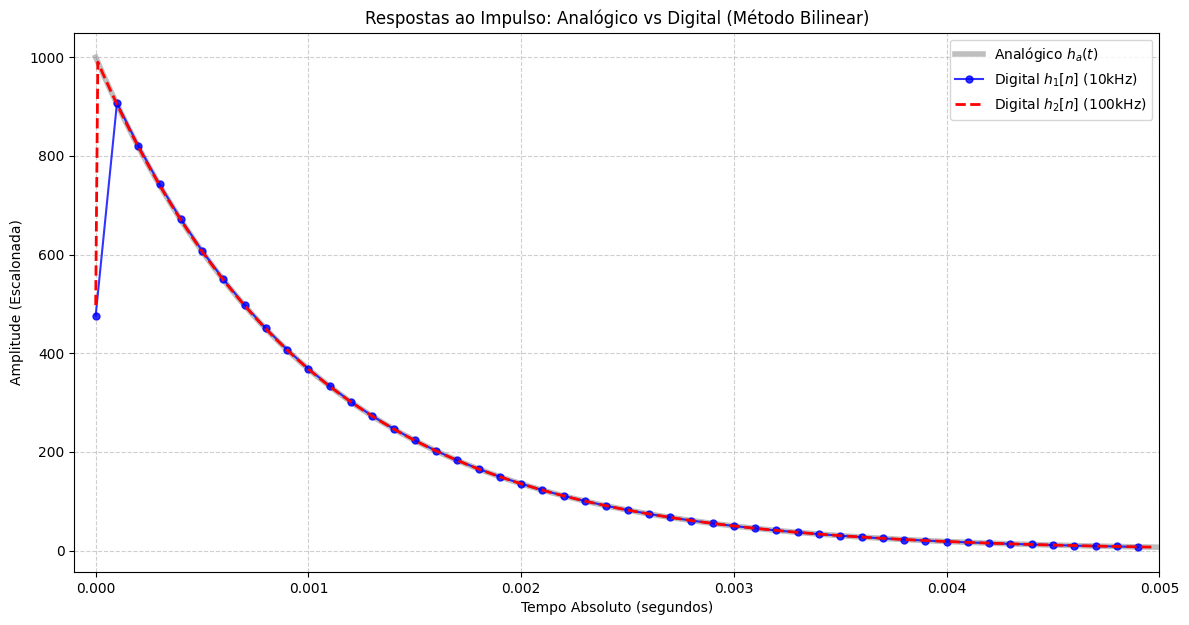

In [ ]:
#Resposta da questão 3c
wc = 1000.0
T1 = 10**-4  # 10%
T2 = 10**-5  # 1%


t_max = 5 * (10**-3)

# Vetor de tempo contínuo
t_a = np.linspace(0, t_max, 1000)

# Vetores discretos de amostras (quantos 'n' cabem em t_max)
n1 = np.arange(0, int(t_max / T1))
n2 = np.arange(0, int(t_max / T2))

# Tempos discretos para o eixo X
t_d1 = n1 * T1
t_d2 = n2 * T2

# Resposta Analógica h_a(t)
ha_t = wc * np.exp(-wc * t_a)


impulso1 = np.zeros(len(n1))
impulso1[0] = 1.0

h1_n = np.zeros(len(n1))
for n in range(len(n1)):
    h1_n_1 = h1_n[n-1] if n >= 1 else 0.0
    x_n_1 = impulso1[n-1] if n >= 1 else 0.0
    # Equação de H1(z)
    h1_n[n] = (19/21)*h1_n_1 + (1/21)*impulso1[n] + (1/21)*x_n_1

# 4. Resposta Discreta h2[n]
impulso2 = np.zeros(len(n2))
impulso2[0] = 1.0

h2_n = np.zeros(len(n2))
for n in range(len(n2)):
    h2_n_1 = h2_n[n-1] if n >= 1 else 0.0
    x_n_1 = impulso2[n-1] if n >= 1 else 0.0
    # Equação de H2(z)
    h2_n[n] = (199/201)*h2_n_1 + (1/201)*impulso2[n] + (1/201)*x_n_1

plt.figure(figsize=(14, 7))

# Analógico
plt.plot(t_a, ha_t, 'gray', linewidth=4, alpha=0.5, label='Analógico $h_a(t)$')

# Digital
plt.plot(t_d1, h1_n / T1, 'bo-', linewidth=1.5, markersize=5, label='Digital $h_1[n]$ (10kHz)', alpha=0.8)

#Digital
plt.plot(t_d2, h2_n / T2, 'r--', linewidth=2, label='Digital $h_2[n]$ (100kHz)')

plt.title('Respostas ao Impulso: Analógico vs Digital (Método Bilinear)')
plt.xlabel('Tempo Absoluto (segundos)')
plt.ylabel('Amplitude (Escalonada)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.0001, t_max)
plt.show()

## Questão 3d (2 pontos)

Considere o sinal:
$$ x\left(t\right) = e^{- \lambda t} u\left(t\right)$$

com

$$\lambda = 500 $$

Calcule a resposta teórica do filtro analógico, y(t), bem como a resposta do filtro digital H1(z) ao sinal amostrado com taxa T1 (x1[n]) e a resposta do filtro digital H2(z) ao sinal amostrado com taxa T2 (x2[n]). **Plote**, na mesma escala, o sinal y(t) e as aproximações y1[n] e y2[n].

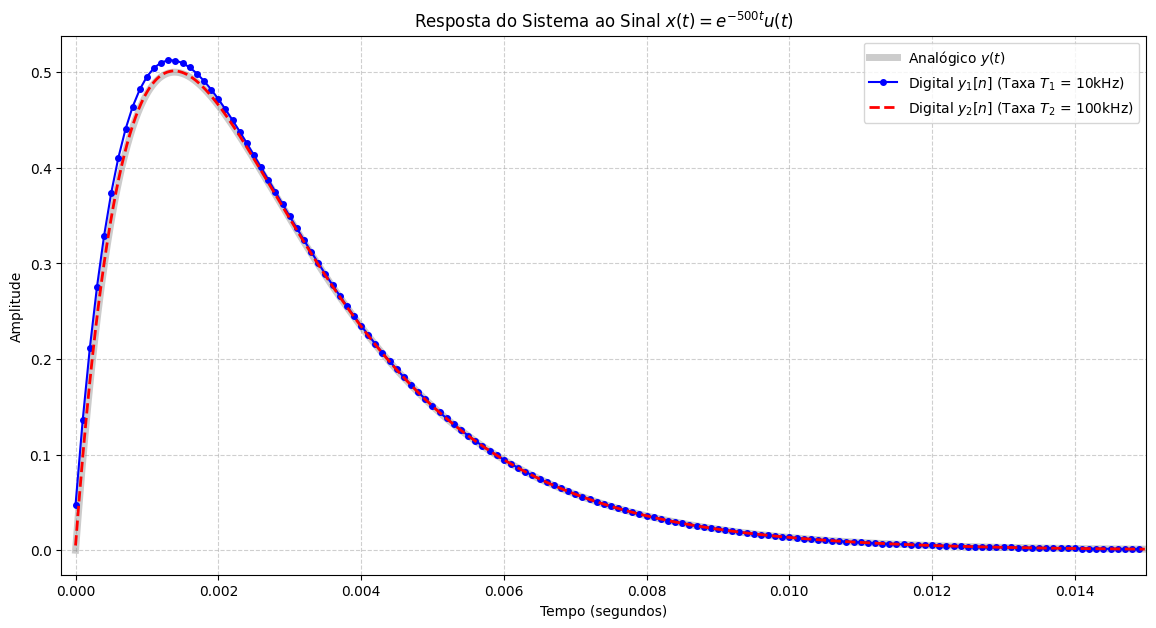

In [ ]:
#Resposta da questão 3d
lamb = 500
t_max = 0.015

# Vetor contínuo e vetores discretos (quantas amostras cabem em t_max)
t_a = np.linspace(0, t_max, 2000)
n1 = np.arange(0, int(t_max / T1))
n2 = np.arange(0, int(t_max / T2))

# Tempos para o eixo x
t_d1 = n1 * T1
t_d2 = n2 * T2

# Resposta Analógica
y_t = 2 * (np.exp(-500 * t_a) - np.exp(-1000 * t_a))

# Sinais de entrada amostrados
x1_n = np.exp(-lamb * t_d1)
x2_n = np.exp(-lamb * t_d2)

# Resposta Digital 10%
y1_n = np.zeros(len(n1))
for n in range(len(n1)):
    y1_n_1 = y1_n[n-1] if n >= 1 else 0.0
    x1_n_1 = x1_n[n-1] if n >= 1 else 0.0
    # A equação de diferenças do H1(z)
    y1_n[n] = (19/21)*y1_n_1 + (1/21)*x1_n[n] + (1/21)*x1_n_1

# Resposta Digital 1%
y2_n = np.zeros(len(n2))
for n in range(len(n2)):
    y2_n_1 = y2_n[n-1] if n >= 1 else 0.0
    x2_n_1 = x2_n[n-1] if n >= 1 else 0.0
    # A equação de diferenças do H2(z)
    y2_n[n] = (199/201)*y2_n_1 + (1/201)*x2_n[n] + (1/201)*x2_n_1

plt.figure(figsize=(14, 7))

# A verdade absoluta (Analógico)
plt.plot(t_a, y_t, 'gray', linewidth=5, alpha=0.4, label='Analógico $y(t)$')

# As aproximações digitais
plt.plot(t_d1, y1_n, 'bo-', linewidth=1.5, markersize=4, label='Digital $y_1[n]$ (Taxa $T_1$ = 10kHz)')

# Usando linha tracejada para T2 pela alta densidade de pontos
plt.plot(t_d2, y2_n, 'r--', linewidth=2, label='Digital $y_2[n]$ (Taxa $T_2$ = 100kHz)')

plt.title('Resposta do Sistema ao Sinal $x(t) = e^{-500t}u(t)$')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.0002, t_max)
plt.show()